# 🧠 Neuro-Sign | Phase 2: LSTM Model Training

This notebook trains an LSTM neural network to classify hand gestures based on sequences of hand landmark coordinates collected in Phase 1.

**Pipeline:**
1. Load `.npy` sequence files from `../data/<GestureName>/`
2. Create labels and split into train/val/test sets
3. Build a stacked LSTM classifier
4. Train with early stopping
5. Visualize accuracy/loss curves
6. Save the trained model

## 1. Install Dependencies
Run this cell once to ensure all required packages are installed.

In [12]:
# Install required packages (run once)
%pip install tensorflow numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Required Libraries

In [13]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Suppress TensorFlow info logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.20.0
NumPy version: 2.4.2


## 3. Configuration

Define paths and constants for the training pipeline.

In [14]:
# ─────────────────────────────────────────────────────────────
# PATHS (relative to this notebook's location)
# ─────────────────────────────────────────────────────────────
DATA_DIR        = "../data"
MODEL_DIR       = "../saved_models"
MODEL_PATH      = os.path.join(MODEL_DIR, "action_model.keras")
LABELS_PATH     = os.path.join(MODEL_DIR, "gesture_labels.json")

# ─────────────────────────────────────────────────────────────
# DATA SHAPE
# ─────────────────────────────────────────────────────────────
SEQUENCE_LENGTH = 30      # frames per sequence
NUM_FEATURES    = 126     # 2 hands × 21 landmarks × (x, y, z)

# ─────────────────────────────────────────────────────────────
# TRAINING HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────
EPOCHS          = 150
BATCH_SIZE      = 32
TEST_SPLIT      = 0.15
VAL_SPLIT       = 0.15
RANDOM_STATE    = 42

print("✔ Configuration loaded")

✔ Configuration loaded


## 4. Load Sequence Data from `.npy` Files

Iterate through each gesture folder and load all recorded sequences. Each sequence file has shape `(30, 126)` — 30 frames with 126 features per frame (2 hands × 21 landmarks × 3 coordinates).

In [15]:
def load_dataset(data_dir: str):
    """
    Loads all gesture sequences from data/<GestureName>/sequence_*.npy
    
    Returns:
        X: ndarray of shape (num_samples, SEQUENCE_LENGTH, NUM_FEATURES)
        y: ndarray of shape (num_samples,) — integer labels
        label_map: dict {gesture_name: int}
    """
    sequences = []
    labels    = []
    label_map = {}
    
    # Get sorted list of gesture folders
    gesture_folders = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])
    
    if not gesture_folders:
        raise FileNotFoundError(
            f"No gesture folders found in {data_dir}.\n"
            "Run collect_data.py first to record some gestures."
        )
    
    print(f"Found {len(gesture_folders)} gesture(s):\n")
    
    for idx, gesture in enumerate(gesture_folders):
        label_map[gesture] = idx
        gesture_dir = os.path.join(data_dir, gesture)
        
        npy_files = sorted([
            f for f in os.listdir(gesture_dir)
            if f.endswith(".npy")
        ])
        
        print(f"  [{idx}] {gesture:20s} → {len(npy_files):3d} sequences")
        
        for npy_file in npy_files:
            seq = np.load(os.path.join(gesture_dir, npy_file))
            
            # Validate shape
            if seq.shape == (SEQUENCE_LENGTH, NUM_FEATURES):
                sequences.append(seq)
                labels.append(idx)
            else:
                print(f"      ⚠ Skipping {npy_file} — unexpected shape {seq.shape}")
    
    X = np.array(sequences, dtype=np.float32)
    y = np.array(labels,    dtype=np.int32)
    
    return X, y, label_map


# Load the dataset
X, y, label_map = load_dataset(DATA_DIR)

print(f"\n{'─' * 50}")
print(f"Total samples : {len(X)}")
print(f"Gesture count : {len(label_map)}")
print(f"X shape       : {X.shape}")
print(f"y shape       : {y.shape}")

Found 5 gesture(s):

  [0] Heart                →  36 sequences
  [1] Peace                →  34 sequences
  [2] Perfect              →  27 sequences
  [3] ThumbsUp             →  25 sequences
  [4] Wave                 →  23 sequences

──────────────────────────────────────────────────
Total samples : 145
Gesture count : 5
X shape       : (145, 30, 126)
y shape       : (145,)


## 5. Split Data and Convert Labels to Categorical

Split into train/validation/test sets (70/15/15) and one-hot encode the labels.

In [16]:
num_classes = len(label_map)

# Check minimum samples per class for stratified split
from collections import Counter
class_counts = Counter(y)
min_samples = min(class_counts.values())

print(f"Samples per gesture: {dict(class_counts)}")
print(f"Minimum samples in a class: {min_samples}\n")

# Adaptive splitting based on dataset size
if min_samples < 3:
    print("⚠ Very small dataset — using simple random split (no stratify)")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=RANDOM_STATE
    )
else:
    # Stratified split preserves class distribution
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SPLIT, random_state=RANDOM_STATE, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, 
        test_size=VAL_SPLIT / (1 - TEST_SPLIT),
        random_state=RANDOM_STATE, 
        stratify=y_train
    )

print(f"Train samples : {len(X_train)}")
print(f"Val samples   : {len(X_val)}")
print(f"Test samples  : {len(X_test)}")

# Convert labels to one-hot encoded (categorical)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val,   num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

print(f"\ny_train_cat shape: {y_train_cat.shape}")
print(f"y_val_cat shape  : {y_val_cat.shape}")
print(f"y_test_cat shape : {y_test_cat.shape}")

Samples per gesture: {np.int32(0): 36, np.int32(1): 34, np.int32(2): 27, np.int32(3): 25, np.int32(4): 23}
Minimum samples in a class: 23

Train samples : 101
Val samples   : 22
Test samples  : 22

y_train_cat shape: (101, 5)
y_val_cat shape  : (22, 5)
y_test_cat shape : (22, 5)


## 6. Build Sequential LSTM Model

A stacked LSTM architecture suited for spatio-temporal time-series classification:

- **Input**: `(30, 126)` — 30 frames × 126 features
- **LSTM layers**: Extract temporal patterns from sequences
- **Dropout layers**: Prevent overfitting
- **Dense layers**: Final classification
- **Output**: Softmax over gesture classes

In [17]:
def build_lstm_model(num_classes: int) -> keras.Model:
    """
    Stacked LSTM classifier for gesture recognition.
    Input:  (batch, 30, 126)
    Output: (batch, num_classes) softmax probabilities
    """
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=(SEQUENCE_LENGTH, NUM_FEATURES), name="input"),
        
        # First LSTM block
        layers.LSTM(64, return_sequences=True, name="lstm_1"),
        layers.Dropout(0.3, name="dropout_1"),
        
        # Second LSTM block
        layers.LSTM(128, return_sequences=True, name="lstm_2"),
        layers.Dropout(0.3, name="dropout_2"),
        
        # Third LSTM block (final temporal encoding)
        layers.LSTM(64, return_sequences=False, name="lstm_3"),
        layers.Dropout(0.3, name="dropout_3"),
        
        # Dense classification head
        layers.Dense(64, activation="relu", name="dense_1"),
        layers.Dense(32, activation="relu", name="dense_2"),
        
        # Output layer
        layers.Dense(num_classes, activation="softmax", name="output"),
    ])
    
    return model


# Build the model
model = build_lstm_model(num_classes)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        48,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,525 (795.02 KB)

 Trainable params: 203,525 (795.02 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile Model

- **Optimizer**: Adam with default learning rate
- **Loss**: Categorical cross-entropy (multi-class classification)
- **Metric**: Accuracy

In [18]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("✔ Model compiled successfully")

✔ Model compiled successfully


## 8. Train Model with Early Stopping

**Callbacks:**
- **EarlyStopping**: Stops training if validation loss doesn't improve for 15 epochs
- **ReduceLROnPlateau**: Reduces learning rate when stuck on a plateau

In [19]:
# Define callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

# Train the model
print("🚀 Starting training...\n")

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

print("\n✔ Training complete!")

🚀 Starting training...

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 290ms/step - accuracy: 0.2475 - loss: 1.6137 - val_accuracy: 0.3636 - val_loss: 1.5486 - learning_rate: 0.0010
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3861 - loss: 1.5371 - val_accuracy: 0.3636 - val_loss: 1.4906 - learning_rate: 0.0010
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4158 - loss: 1.4716 - val_accuracy: 0.3636 - val_loss: 1.4287 - learning_rate: 0.0010
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4554 - loss: 1.3963 - val_accuracy: 0.4545 - val_loss: 1.3620 - learning_rate: 0.0010
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.4356 - loss: 1.3280 - val_accuracy: 0.5000 - val_loss: 1.2340 - learning_rate: 0.0010
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4554 - loss: 1.2322 - val_accuracy: 0.5000 - val_loss: 1.1525 - learning_rate: 0.0010
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4950 - lo

## 9. Plot Training Accuracy and Loss

Visualize how the model learned over epochs. Look for:
- **Convergence**: Both curves should stabilize
- **Overfitting**: Training keeps improving but validation gets worse

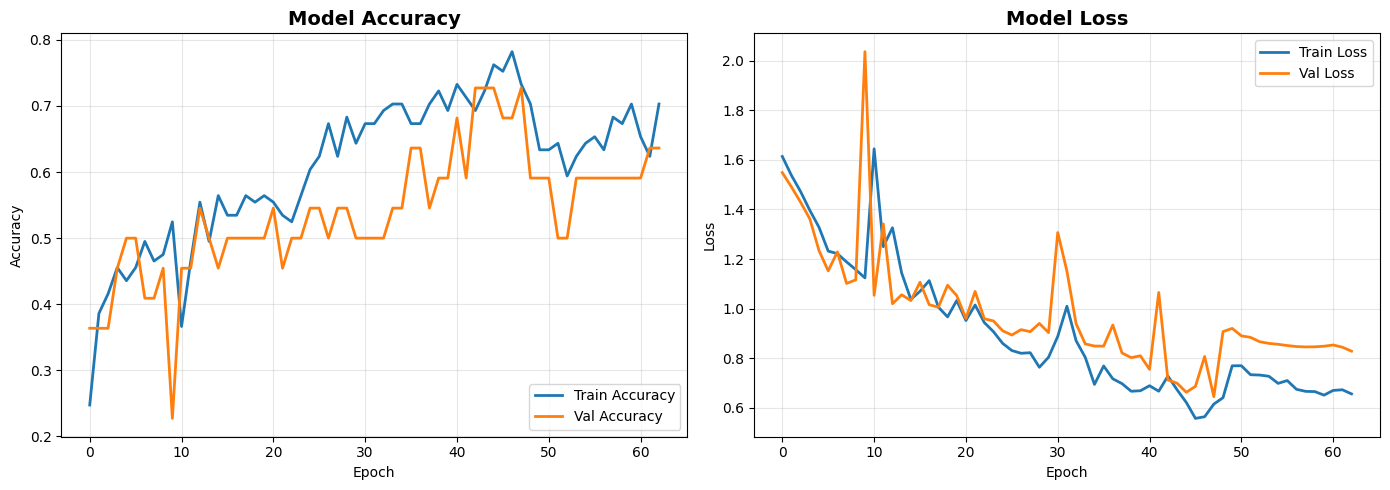

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─────────────────────────────────────────────────────────────
# Accuracy plot
# ─────────────────────────────────────────────────────────────
axes[0].plot(history.history["accuracy"],     label="Train Accuracy", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy",   linewidth=2)
axes[0].set_title("Model Accuracy", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# ─────────────────────────────────────────────────────────────
# Loss plot
# ─────────────────────────────────────────────────────────────
axes[1].plot(history.history["loss"],     label="Train Loss", linewidth=2)
axes[1].plot(history.history["val_loss"], label="Val Loss",   linewidth=2)
axes[1].set_title("Model Loss", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Evaluate on Test Set

Final evaluation on held-out test data that the model has never seen.

In [21]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print("=" * 50)
print("  TEST SET EVALUATION")
print("=" * 50)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 50)

  TEST SET EVALUATION
  Test Loss     : 0.5974
  Test Accuracy : 68.18%


## 11. Save Trained Model and Labels

Save the model to `saved_models/action_model.keras` and the label mapping to JSON for use in the FastAPI backend.

In [22]:
# Create output directory if needed
os.makedirs(MODEL_DIR, exist_ok=True)

# Save the Keras model
model.save(MODEL_PATH)
print(f"✔ Model saved to: {MODEL_PATH}")

# Save label mapping as JSON
with open(LABELS_PATH, "w") as f:
    json.dump(label_map, f, indent=2)
print(f"✔ Labels saved to: {LABELS_PATH}")

# Display the label mapping
print("\n📋 Gesture Label Mapping:")
for gesture, idx in label_map.items():
    print(f"   {idx}: {gesture}")

✔ Model saved to: ../saved_models\action_model.keras
✔ Labels saved to: ../saved_models\gesture_labels.json

📋 Gesture Label Mapping:
   0: Heart
   1: Peace
   2: Perfect
   3: ThumbsUp
   4: Wave


---

## ✅ Done!

Your trained model is now saved at:
```
backend/ml_pipeline/saved_models/action_model.keras
backend/ml_pipeline/saved_models/gesture_labels.json
```

**Next Steps:**
- **Phase 3**: Create the FastAPI backend that loads this model
- **Phase 4**: Build the React frontend with webcam and WebSocket connection